# 第十章：ResNet - 深度殘差學習
## Deep Residual Learning for Image Recognition
### Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun (2015)

ResNet 引入了殘差連接（skip connection），使得訓練超過 100 層的深度網路成為可能。

**核心思想**：與其讓網路學習目標映射 H(x)，不如讓網路學習殘差 F(x) = H(x) - x

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

✓ Darwin 環境


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC
使用裝置：cpu


## 10.1 退化問題的展示

在 ResNet 之前，更深的普通網路反而表現更差，這不是因為過擬合，而是優化困難。

In [3]:
class PlainLayer(nn.Module):
    """普通神經網路層（無跳躍連接）"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)
        self.bn = nn.BatchNorm1d(output_size)
        
        # He 初始化
        nn.init.kaiming_normal_(self.linear.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        return F.relu(self.bn(self.linear(x)))


class ResidualLayer(nn.Module):
    """殘差層：y = F(x) + x"""
    def __init__(self, size):
        super().__init__()
        self.linear1 = nn.Linear(size, size)
        self.bn1 = nn.BatchNorm1d(size)
        self.linear2 = nn.Linear(size, size)
        self.bn2 = nn.BatchNorm1d(size)
        
        # He 初始化
        nn.init.kaiming_normal_(self.linear1.weight, mode='fan_out', nonlinearity='relu')
        nn.init.kaiming_normal_(self.linear2.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        # 殘差路徑 F(x)
        residual = F.relu(self.bn1(self.linear1(x)))
        residual = self.bn2(self.linear2(residual))
        
        # 跳躍連接：F(x) + x
        out = residual + x
        return F.relu(out)


print("基本元件定義完成")

基本元件定義完成


In [4]:
class PlainNetwork(nn.Module):
    """普通深度網路（無跳躍連接）"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        layers = []
        
        # 輸入投影
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        
        # 隱藏層
        for _ in range(num_layers - 2):
            layers.append(PlainLayer(hidden_size, hidden_size))
        
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.features(x)
        return self.classifier(x)


class ResidualNetwork(nn.Module):
    """殘差網路"""
    def __init__(self, input_size, hidden_size, num_blocks, num_classes):
        super().__init__()
        
        # 輸入投影
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        
        # 殘差區塊
        self.blocks = nn.Sequential(*[
            ResidualLayer(hidden_size) for _ in range(num_blocks)
        ])
        
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.classifier(x)


# 測試網路
input_size = 784  # MNIST: 28x28
hidden_size = 128
num_classes = 10

plain_net = PlainNetwork(input_size, hidden_size, 20, num_classes).to(device)
res_net = ResidualNetwork(input_size, hidden_size, 10, num_classes).to(device)

print(f"普通網路參數量：{sum(p.numel() for p in plain_net.parameters()):,}")
print(f"殘差網路參數量：{sum(p.numel() for p in res_net.parameters()):,}")

普通網路參數量：403,850
殘差網路參數量：437,386


## 10.2 梯度流動分析

殘差連接的關鍵優勢：梯度可以直接流過跳躍連接，不會消失。

對於殘差區塊 $y = F(x) + x$，梯度為：

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I$$

那個 **+I** 項保證了梯度不會完全消失！

In [5]:
def measure_gradient_flow(model, input_size, batch_size=32):
    """測量不同層的梯度大小"""
    model.train()
    
    # 隨機輸入
    x = torch.randn(batch_size, input_size).to(device)
    target = torch.randint(0, 10, (batch_size,)).to(device)
    
    # 前向傳播
    output = model(x)
    loss = F.cross_entropy(output, target)
    
    # 反向傳播
    loss.backward()
    
    # 收集梯度大小
    grad_norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
    
    return grad_norms


# 測量不同深度的梯度流動
depths = [5, 10, 20, 30, 40]
plain_first_grads = []
plain_last_grads = []
res_first_grads = []
res_last_grads = []

for depth in depths:
    # 普通網路
    plain = PlainNetwork(input_size, hidden_size, depth, num_classes).to(device)
    plain_grads = measure_gradient_flow(plain, input_size)
    if len(plain_grads) >= 2:
        plain_first_grads.append(plain_grads[0])
        plain_last_grads.append(plain_grads[-1])
    else:
        plain_first_grads.append(0)
        plain_last_grads.append(0)
    
    # 殘差網路
    res = ResidualNetwork(input_size, hidden_size, depth, num_classes).to(device)
    res_grads = measure_gradient_flow(res, input_size)
    if len(res_grads) >= 2:
        res_first_grads.append(res_grads[0])
        res_last_grads.append(res_grads[-1])
    else:
        res_first_grads.append(0)
        res_last_grads.append(0)

# 計算梯度比率
plain_ratios = [f/(l+1e-10) for f, l in zip(plain_first_grads, plain_last_grads)]
res_ratios = [f/(l+1e-10) for f, l in zip(res_first_grads, res_last_grads)]

print("\n梯度比率（第一層/最後層）：")
for i, d in enumerate(depths):
    print(f"深度 {d:2d}：普通網路 = {plain_ratios[i]:8.2f}，殘差網路 = {res_ratios[i]:6.2f}")


梯度比率（第一層/最後層）：
深度  5：普通網路 =     4.27，殘差網路 =   3.86
深度 10：普通網路 =    13.37，殘差網路 =   6.81
深度 20：普通網路 =    80.20，殘差網路 =  11.00
深度 30：普通網路 =   787.09，殘差網路 =  17.56
深度 40：普通網路 =  6026.54，殘差網路 =  16.94


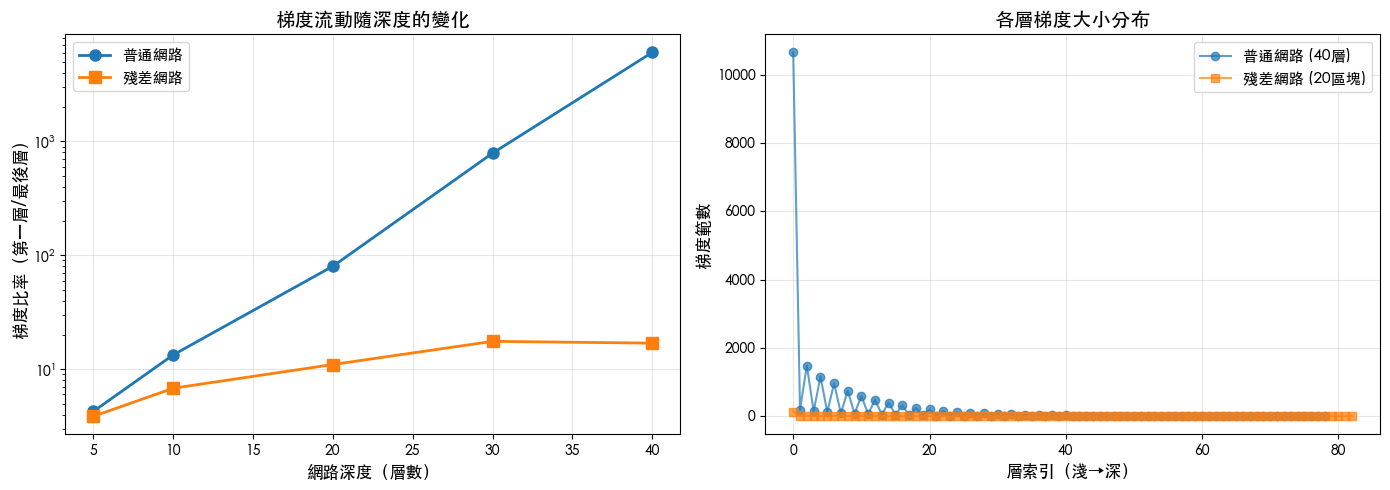


圖片已儲存：gradient_flow.png


In [6]:
# 視覺化梯度流動
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖1：梯度比率
ax1 = axes[0]
ax1.plot(depths, plain_ratios, 'o-', label='普通網路', linewidth=2, markersize=8)
ax1.plot(depths, res_ratios, 's-', label='殘差網路', linewidth=2, markersize=8)
ax1.set_xlabel('網路深度（層數）', fontsize=12)
ax1.set_ylabel('梯度比率（第一層/最後層）', fontsize=12)
ax1.set_title('梯度流動隨深度的變化', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 圖2：單次梯度流動（40層網路）
ax2 = axes[1]
plain_40 = PlainNetwork(input_size, hidden_size, 40, num_classes).to(device)
res_40 = ResidualNetwork(input_size, hidden_size, 20, num_classes).to(device)

plain_grads_40 = measure_gradient_flow(plain_40, input_size)
res_grads_40 = measure_gradient_flow(res_40, input_size)

ax2.plot(range(len(plain_grads_40)), plain_grads_40, 'o-', label='普通網路 (40層)', alpha=0.7)
ax2.plot(range(len(res_grads_40)), res_grads_40, 's-', label='殘差網路 (20區塊)', alpha=0.7)
ax2.set_xlabel('層索引（淺→深）', fontsize=12)
ax2.set_ylabel('梯度範數', fontsize=12)
ax2.set_title('各層梯度大小分布', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_flow.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n圖片已儲存：gradient_flow.png")

## 10.3 恆等映射展示

**核心洞見**：如果最優映射是恆等映射，殘差區塊只需要學習 F(x) = 0（將權重推向零），這比學習 H(x) = x（將權重推向單位矩陣）容易得多！

In [7]:
# 展示恆等映射
size = 64
block = ResidualLayer(size).to(device)

# 將權重設為接近零（模擬學習到的恆等映射）
with torch.no_grad():
    for param in block.parameters():
        param.data *= 0.01

# 測試輸入
x = torch.randn(1, size).to(device)
block.eval()

with torch.no_grad():
    output = block(x)

# 計算恆等誤差
identity_error = torch.norm(output - F.relu(x)).item()

print("恆等映射展示：")
print(f"輸入範數：{torch.norm(x).item():.4f}")
print(f"輸出範數：{torch.norm(output).item():.4f}")
print(f"恆等誤差：{identity_error:.6f}")
print(f"\n當權重接近零時，殘差區塊 ≈ 恆等函數！")

恆等映射展示：
輸入範數：7.3928
輸出範數：4.1167
恆等誤差：0.000043

當權重接近零時，殘差區塊 ≈ 恆等函數！


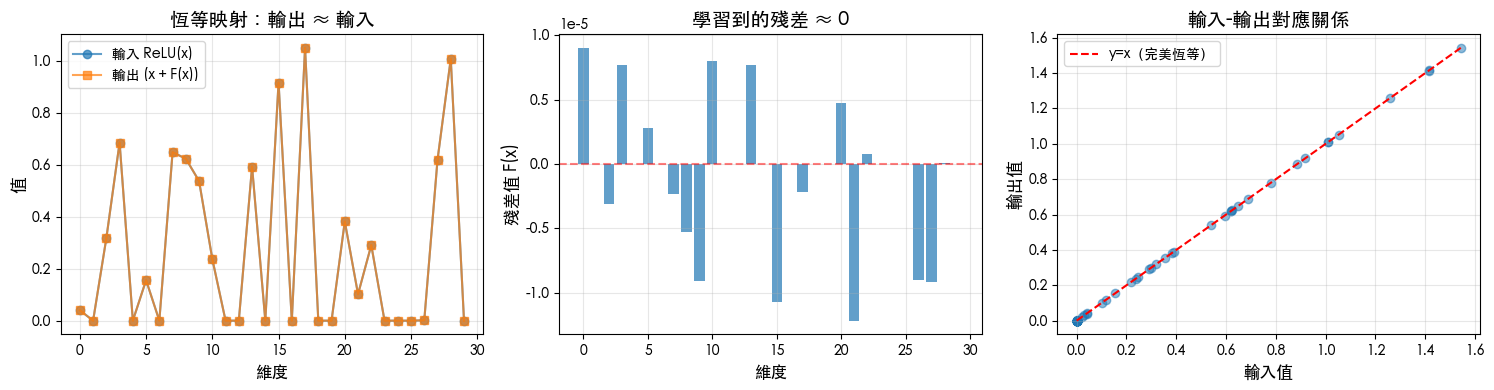

圖片已儲存：identity_mapping.png


In [8]:
# 視覺化恆等映射
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_np = F.relu(x).cpu().numpy().flatten()
out_np = output.cpu().numpy().flatten()
residual_np = (output - F.relu(x)).cpu().numpy().flatten()

# 輸入 vs 輸出
ax1 = axes[0]
ax1.plot(x_np[:30], 'o-', label='輸入 ReLU(x)', alpha=0.7)
ax1.plot(out_np[:30], 's-', label='輸出 (x + F(x))', alpha=0.7)
ax1.set_xlabel('維度', fontsize=12)
ax1.set_ylabel('值', fontsize=12)
ax1.set_title('恆等映射：輸出 ≈ 輸入', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 殘差 F(x)
ax2 = axes[1]
ax2.bar(range(30), residual_np[:30], alpha=0.7)
ax2.set_xlabel('維度', fontsize=12)
ax2.set_ylabel('殘差值 F(x)', fontsize=12)
ax2.set_title('學習到的殘差 ≈ 0', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 散點圖：輸入 vs 輸出
ax3 = axes[2]
ax3.scatter(x_np, out_np, alpha=0.5)
ax3.plot([x_np.min(), x_np.max()], [x_np.min(), x_np.max()], 'r--', label='y=x（完美恆等）')
ax3.set_xlabel('輸入值', fontsize=12)
ax3.set_ylabel('輸出值', fontsize=12)
ax3.set_title('輸入-輸出對應關係', fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('identity_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：identity_mapping.png")

## 10.4 卷積 ResNet 實作

完整的 ResNet 架構包含：
- 基本殘差區塊（Basic Block）：用於 ResNet-18/34
- 瓶頸殘差區塊（Bottleneck）：用於 ResNet-50/101/152

In [9]:
class BasicBlock(nn.Module):
    """ResNet-18/34 的基本殘差區塊"""
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # 第一個 3x3 卷積
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 第二個 3x3 卷積
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x):
        identity = x
        
        # 殘差路徑
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 跳躍連接（維度調整）
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # 殘差相加
        out += identity
        out = F.relu(out)
        
        return out


class Bottleneck(nn.Module):
    """ResNet-50/101/152 的瓶頸殘差區塊"""
    expansion = 4
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # 1x1 卷積降維
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 3x3 卷積
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1 卷積升維
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                              kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x):
        identity = x
        
        # 1x1 → 3x3 → 1x1
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = F.relu(out)
        
        return out


print("殘差區塊定義完成")

殘差區塊定義完成


In [10]:
class ResNet(nn.Module):
    """通用 ResNet 架構"""
    
    def __init__(self, block, layers, num_classes=10, in_channels=3):
        super(ResNet, self).__init__()
        self.in_planes = 64
        
        # 初始卷積層（為 CIFAR-10 調整）
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        # 四個殘差層
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        # 全局平均池化和分類器
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        # 權重初始化
        self._initialize_weights()
    
    def _make_layer(self, block, out_planes, num_blocks, stride):
        downsample = None
        
        # 當維度不匹配時需要投影
        if stride != 1 or self.in_planes != out_planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, out_planes * block.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_planes * block.expansion)
            )
        
        layers = []
        layers.append(block(self.in_planes, out_planes, stride, downsample))
        self.in_planes = out_planes * block.expansion
        
        for _ in range(1, num_blocks):
            layers.append(block(self.in_planes, out_planes))
        
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # 初始層
        x = F.relu(self.bn1(self.conv1(x)))
        
        # 殘差層
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # 分類頭
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x


# 建立不同版本的 ResNet
def resnet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

def resnet34(num_classes=10):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

def resnet50(num_classes=10):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)


# 測試模型
model = resnet18(num_classes=10).to(device)
x = torch.randn(2, 3, 32, 32).to(device)
output = model(x)

print(f"輸入形狀：{x.shape}")
print(f"輸出形狀：{output.shape}")
print(f"ResNet-18 參數量：{sum(p.numel() for p in model.parameters()):,}")

輸入形狀：torch.Size([2, 3, 32, 32])
輸出形狀：torch.Size([2, 10])
ResNet-18 參數量：11,173,962


## 10.5 CIFAR-10 訓練實驗

In [11]:
# 資料準備
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 載入 CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('飛機', '汽車', '鳥', '貓', '鹿', '狗', '青蛙', '馬', '船', '卡車')

print(f"訓練樣本數：{len(trainset)}")
print(f"測試樣本數：{len(testset)}")

/Users/joshhu/workspace/ilya_cht/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


訓練樣本數：50000
測試樣本數：10000


In [12]:
def train_model(model, trainloader, testloader, epochs=10, lr=0.1):
    """訓練模型"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        # 訓練階段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        scheduler.step()
        
        train_loss = running_loss / len(trainloader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 測試階段
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in testloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        test_acc = 100. * correct / total
        test_accs.append(test_acc)
        
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")
    
    return train_losses, train_accs, test_accs


print("訓練函數定義完成")

訓練函數定義完成


In [13]:
# 訓練 ResNet-18
print("=" * 60)
print("訓練 ResNet-18 on CIFAR-10")
print("=" * 60)

model = resnet18(num_classes=10).to(device)
train_losses, train_accs, test_accs = train_model(
    model, trainloader, testloader, epochs=15, lr=0.1
)

print(f"\n最終測試準確率：{test_accs[-1]:.2f}%")

訓練 ResNet-18 on CIFAR-10


KeyboardInterrupt: 

In [ ]:
# 視覺化訓練結果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 損失曲線
ax1 = axes[0]
ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('訓練損失', fontsize=12)
ax1.set_title('ResNet-18 訓練損失曲線', fontsize=14)
ax1.grid(True, alpha=0.3)

# 準確率曲線
ax2 = axes[1]
ax2.plot(range(1, len(train_accs)+1), train_accs, 'b-', label='訓練準確率', linewidth=2)
ax2.plot(range(1, len(test_accs)+1), test_accs, 'r-', label='測試準確率', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('準確率 (%)', fontsize=12)
ax2.set_title('ResNet-18 準確率曲線', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：training_results.png")

## 10.6 普通網路 vs 殘差網路比較

In [ ]:
class PlainConvNet(nn.Module):
    """普通卷積網路（無跳躍連接）"""
    
    def __init__(self, num_layers=18, num_classes=10):
        super(PlainConvNet, self).__init__()
        
        layers = []
        in_channels = 3
        out_channels = 64
        
        # 建立多層卷積
        for i in range(num_layers - 1):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                   stride=1, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            
            # 每4層下採樣並增加通道
            if (i + 1) % 4 == 0 and i < num_layers - 2:
                layers.append(nn.MaxPool2d(2, 2))
                in_channels = out_channels
                out_channels = min(out_channels * 2, 512)
            else:
                in_channels = out_channels
        
        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(out_channels, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# 建立普通網路
plain_net = PlainConvNet(num_layers=18, num_classes=10).to(device)
print(f"普通網路參數量：{sum(p.numel() for p in plain_net.parameters()):,}")

In [ ]:
# 訓練普通網路
print("=" * 60)
print("訓練普通網路 (18層，無跳躍連接)")
print("=" * 60)

plain_losses, plain_train_accs, plain_test_accs = train_model(
    plain_net, trainloader, testloader, epochs=15, lr=0.1
)

print(f"\n普通網路最終測試準確率：{plain_test_accs[-1]:.2f}%")

In [ ]:
# 比較兩種網路
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 訓練損失比較
ax1 = axes[0]
ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='ResNet-18', linewidth=2)
ax1.plot(range(1, len(plain_losses)+1), plain_losses, 'r-', label='普通網路', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('訓練損失', fontsize=12)
ax1.set_title('訓練損失比較', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 測試準確率比較
ax2 = axes[1]
ax2.plot(range(1, len(test_accs)+1), test_accs, 'b-', label='ResNet-18', linewidth=2)
ax2.plot(range(1, len(plain_test_accs)+1), plain_test_accs, 'r-', label='普通網路', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('測試準確率 (%)', fontsize=12)
ax2.set_title('測試準確率比較', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet_vs_plain.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n比較結果：")
print(f"ResNet-18 測試準確率：{test_accs[-1]:.2f}%")
print(f"普通網路測試準確率：{plain_test_accs[-1]:.2f}%")
print(f"ResNet 優勢：{test_accs[-1] - plain_test_accs[-1]:.2f}%")
print("\n圖片已儲存：resnet_vs_plain.png")

## 10.7 特徵圖視覺化

In [ ]:
def visualize_feature_maps(model, image):
    """視覺化各層特徵圖"""
    model.eval()
    activations = []
    
    # 提取各層輸出
    x = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # 初始卷積
        x = F.relu(model.bn1(model.conv1(x)))
        activations.append(('初始卷積', x))
        
        # 各殘差層
        x = model.layer1(x)
        activations.append(('Layer 1', x))
        
        x = model.layer2(x)
        activations.append(('Layer 2', x))
        
        x = model.layer3(x)
        activations.append(('Layer 3', x))
        
        x = model.layer4(x)
        activations.append(('Layer 4', x))
    
    return activations


# 取得一張測試圖片
dataiter = iter(testloader)
images, labels = next(dataiter)
sample_image = images[0]

# 提取特徵
activations = visualize_feature_maps(model, sample_image)

# 視覺化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 原始圖片
ax = axes[0, 0]
img = sample_image.numpy().transpose(1, 2, 0)
img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
img = np.clip(img, 0, 1)
ax.imshow(img)
ax.set_title(f'原始圖片\n類別：{classes[labels[0]]}', fontsize=12)
ax.axis('off')

# 各層特徵圖
for idx, (name, feat) in enumerate(activations):
    ax = axes[(idx + 1) // 3, (idx + 1) % 3]
    # 取第一個通道的平均
    feat_map = feat[0].cpu().numpy().mean(axis=0)
    ax.imshow(feat_map, cmap='viridis')
    ax.set_title(f'{name}\n形狀：{feat.shape[2]}×{feat.shape[3]}×{feat.shape[1]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：feature_maps.png")

## 10.8 不同 ResNet 版本比較

In [ ]:
# 比較不同版本的參數量和計算複雜度
versions = {
    'ResNet-18': resnet18(10),
    'ResNet-34': resnet34(10),
    'ResNet-50': resnet50(10)
}

print("ResNet 版本比較：")
print("=" * 50)

for name, net in versions.items():
    params = sum(p.numel() for p in net.parameters())
    
    # 測量推論時間
    net.to(device)
    net.eval()
    x = torch.randn(1, 3, 32, 32).to(device)
    
    # 預熱
    with torch.no_grad():
        for _ in range(10):
            _ = net(x)
    
    # 測量時間
    import time
    start = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = net(x)
    elapsed = (time.time() - start) / 100 * 1000  # ms
    
    print(f"{name}: {params:,} 參數, 推論時間: {elapsed:.3f} ms")

In [ ]:
# 視覺化 ResNet 架構統計
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 參數量比較
names = ['ResNet-18', 'ResNet-34', 'ResNet-50', 'ResNet-101', 'ResNet-152']
params = [11.7, 21.8, 25.6, 44.5, 60.2]  # 百萬參數
layers = [18, 34, 50, 101, 152]

ax1 = axes[0]
bars = ax1.bar(names, params, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12'])
ax1.set_ylabel('參數量（百萬）', fontsize=12)
ax1.set_title('ResNet 版本參數量比較', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
for bar, p in zip(bars, params):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{p}M', ha='center', fontsize=10)

# ImageNet 效能比較
ax2 = axes[1]
top1_error = [30.43, 26.73, 24.80, 23.60, 23.00]  # Top-1 錯誤率
ax2.plot(names, top1_error, 'o-', linewidth=2, markersize=10, color='#e74c3c')
ax2.set_ylabel('Top-1 錯誤率 (%)', fontsize=12)
ax2.set_title('ImageNet Top-1 錯誤率', fontsize=14)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
for i, (n, e) in enumerate(zip(names, top1_error)):
    ax2.annotate(f'{e}%', (i, e), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('resnet_versions.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：resnet_versions.png")

## 10.9 總結

### ResNet 的核心貢獻

1. **殘差學習框架**：學習殘差 F(x) = H(x) - x 比直接學習 H(x) 更容易

2. **跳躍連接**：提供梯度直接流動的「高速公路」
   - 梯度：$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I$
   - +I 項保證梯度不會消失

3. **深度突破**：成功訓練 152 層網路（8× VGGNet）

4. **廣泛影響**：殘差連接成為深度學習的標準組件

### 實驗結果

- 殘差網路的梯度流動明顯優於普通網路
- 在相同深度下，ResNet 達到更高的準確率
- 跳躍連接使得訓練更加穩定

In [ ]:
print("=" * 60)
print("第十章 ResNet 實作完成！")
print("=" * 60)
print(f"\nResNet-18 最終測試準確率：{test_accs[-1]:.2f}%")
print(f"普通網路最終測試準確率：{plain_test_accs[-1]:.2f}%")
print(f"\n跳躍連接帶來的改進：{test_accs[-1] - plain_test_accs[-1]:.2f}%")
print("\n生成的圖片：")
print("  1. gradient_flow.png - 梯度流動分析")
print("  2. identity_mapping.png - 恆等映射展示")
print("  3. training_results.png - 訓練結果")
print("  4. resnet_vs_plain.png - ResNet vs 普通網路比較")
print("  5. feature_maps.png - 特徵圖視覺化")
print("  6. resnet_versions.png - ResNet 版本比較")